# Day 4: Enrichment & Expression Analysis
## Bioinformatics Course - IMBB-FORTH

**Lesson 4** Understanding enrichment logic and applying it to gene expression.

### Objectives
By the end of this session, you will:
- Understand enrichment analysis through a concrete toy example
- Compare gene expression between conditions
- Identify differentially expressed genes
- See how enrichment applies to GO terms

---

## 1. Setup

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import hypergeom
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Base URL for loading data from anywhere
REPO = "https://raw.githubusercontent.com/cgenomicslab/imbb-data-analysis/main"

print("Libraries loaded.")

---

## 2. Enrichment: The Colored Balls Example

Imagine a bag with **100 balls** of 5 colors:

| Color | Count |
|-------|-------|
| Purple | 20 |
| Red | 30 |
| Blue | 25 |
| Green | 15 |
| Yellow | 10 |

You grab a **subset of 15 balls** and count: **8 are purple**.

Purple is 20% of the bag, so you'd expect about 3 purple in 15 draws. But you got 8.

**Is purple enriched in your subset, or was it just luck?**

### The concept

The large circle is the population. The small circle is our subset. Notice how purple is over-represented in the subset.

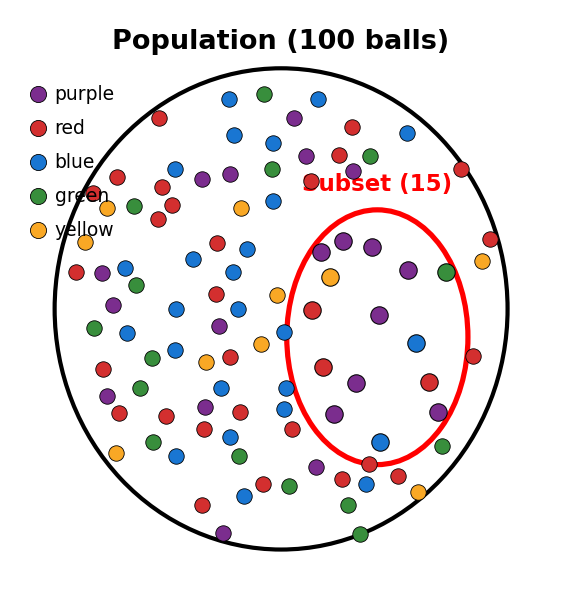

### Expected vs Observed

In [ ]:
# The population
population = ['purple'] * 20 + ['red'] * 30 + ['blue'] * 25 + ['green'] * 15 + ['yellow'] * 10

# What we observed in our subset of 15
observed = {'purple': 8, 'red': 3, 'blue': 2, 'green': 1, 'yellow': 1}
subset_size = 15

# Compare expected vs observed
colors = ['purple', 'red', 'blue', 'green', 'yellow']
pop_counts = [20, 30, 25, 15, 10]

print(f"{'Color':<10s} {'Expected':<10s} {'Observed':<10s} {'Fold enrichment'}")
print("-" * 45)
for color, pop_n in zip(colors, pop_counts):
    exp = subset_size * pop_n / 100
    obs = observed[color]
    fold = obs / exp
    print(f"{color:<10s} {exp:<10.1f} {obs:<10d} {fold:.2f}x")

### Is it significant? Permutation test

Same logic as Day 3: randomly grab 15 balls from the bag thousands of times. How often do we get ≥8 purple?

In [ ]:
# Permutation test
np.random.seed(42)
n_permutations = 10000
purple_counts = []

for i in range(n_permutations):
    random_grab = np.random.choice(population, size=subset_size, replace=False)
    purple_counts.append(np.sum(random_grab == 'purple'))

purple_counts = np.array(purple_counts)

# Plot
sns.histplot(purple_counts, bins=range(0, 13), discrete=True, color='steelblue')
plt.axvline(8, color='red', linewidth=2, label='Observed: 8 purple')
plt.xlabel('Purple balls in random subset of 15')
plt.legend()
plt.show()

p_perm = np.sum(purple_counts >= 8) / n_permutations
print(f"P-value: {p_perm}")

### The hypergeometric test

The [hypergeometric distribution](https://en.wikipedia.org/wiki/Hypergeometric_distribution) calculates the exact probability of drawing a certain number of "special" items from a population **without replacement**.

It takes four numbers:
- **M**: total population (100 balls)
- **n**: special items in population (20 purple)
- **N**: how many we drew (15)
- **k**: special items we observed (8)

This is the standard test used in GO enrichment tools.

In [ ]:
# Hypergeometric test: exact p-value
p_hyper = hypergeom.sf(7, M=100, n=20, N=15)  # P(X >= 8)

print(f"Permutation p-value:    {p_perm}")
print(f"Hypergeometric p-value: {p_hyper:.4f}")
print()
print("Both agree: purple is significantly enriched.")

### 💡 Exercise 4.1: Test All Colors

**Task:** For each color, calculate the fold enrichment and hypergeometric p-value.
Which colors are enriched? Which are depleted?

In [ ]:
# Test all colors
print(f"{'Color':<10s} {'Obs':<6s} {'Exp':<6s} {'Fold':<8s} {'P-value':<10s} {'Enriched?'}")
print("-" * 50)

for color, pop_n in zip(colors, pop_counts):
    obs = observed[color]
    exp = subset_size * pop_n / 100
    fold = obs / exp
    p = hypergeom.sf(obs - 1, M=100, n=pop_n, N=subset_size)
    sig = 'Yes' if p < 0.05 else 'No'
    print(f"{color:<10s} {obs:<6d} {exp:<6.1f} {fold:<8.2f} {p:<10.4f} {sig}")

---

## 3. Differential Expression

Now let's work with gene expression data.

We have RNA-seq counts for 100 genes measured in 9 samples from 3 conditions:
Normal, Treatment_A, and Treatment_B (3 replicates each).

**The question:** Which genes change between conditions?

### Load the data

In [ ]:
# Load expression data (samples in rows, genes in columns)
expression = pd.read_csv(REPO + '/data/bulk_rnaseq_counts.csv', index_col=0)
metadata = pd.read_csv(REPO + '/data/bulk_rnaseq_metadata.csv')

print(f"Expression: {expression.shape[0]} samples × {expression.shape[1]} genes")
expression.head()

In [ ]:
metadata

### Look at a single gene

In [ ]:
# Boxplot of Gene_001 across conditions
gene = 'Gene_001'

plot_data = pd.DataFrame({
    'expression': expression[gene].values,
    'condition': metadata['condition'].values
})

sns.boxplot(data=plot_data, x='condition', y='expression')
plt.title(gene)
plt.show()

print(f"{gene} is clearly higher in Treatment_A.")

### Test a single gene

We use the t-test from Day 3 to check if the difference is significant.

In [ ]:
# Get expression values for each condition
normal_samples = metadata[metadata['condition'] == 'Normal']['sample_name'].values
treat_a_samples = metadata[metadata['condition'] == 'Treatment_A']['sample_name'].values

gene = 'Gene_001'
normal_vals = expression.loc[normal_samples, gene].values.astype(float)
treat_a_vals = expression.loc[treat_a_samples, gene].values.astype(float)

# Fold change
fold_change = treat_a_vals.mean() / normal_vals.mean()

# T-test
t_stat, p_value = stats.ttest_ind(normal_vals, treat_a_vals)

print(f"{gene}:")
print(f"  Normal mean:      {normal_vals.mean():.0f}")
print(f"  Treatment_A mean: {treat_a_vals.mean():.0f}")
print(f"  Fold change:      {fold_change:.2f}x")
print(f"  P-value:          {p_value:.6f}")

### Test all genes

Now we loop through all 100 genes.

In [ ]:
# Test all genes: Normal vs Treatment_A
results = []

for gene in expression.columns:
    normal_vals = expression.loc[normal_samples, gene].values.astype(float)
    treat_a_vals = expression.loc[treat_a_samples, gene].values.astype(float)
    
    fc = treat_a_vals.mean() / normal_vals.mean()
    log2_fc = np.log2(fc)
    t, p = stats.ttest_ind(normal_vals, treat_a_vals)
    
    results.append({'gene': gene, 'log2_fc': log2_fc, 'p_value': p})

results_df = pd.DataFrame(results)
print(f"Tested {len(results_df)} genes")
results_df.head()

### How many are differentially expressed?

In [ ]:
# Significant genes
de_genes = results_df[(results_df['p_value'] < 0.05) & (results_df['log2_fc'].abs() > 1)]

up = de_genes[de_genes['log2_fc'] > 0]
down = de_genes[de_genes['log2_fc'] < 0]

print(f"Differentially expressed (p < 0.05 and |fold change| > 2): {len(de_genes)}")
print(f"  Upregulated:   {len(up)}")
print(f"  Downregulated: {len(down)}")

In [ ]:
# Top 10 most significant
top = results_df.sort_values('p_value').head(10)

print(f"{'Gene':<12s} {'Log2 FC':<10s} {'P-value':<12s} {'Direction'}")
print("-" * 45)
for _, row in top.iterrows():
    d = 'Up' if row['log2_fc'] > 0 else 'Down'
    print(f"{row['gene']:<12s} {row['log2_fc']:<10.2f} {row['p_value']:<12.6f} {d}")

### 💡 Exercise 4.2: Visualize a DE Gene

**Task:** Pick one of the top DE genes from the table above.
1. Create a boxplot of its expression across all 3 conditions
2. Is it also different in Treatment_B compared to Normal?

In [ ]:
# Your code here
gene = # Pick a gene from the top list

plot_data = pd.DataFrame({
    'expression': expression[gene].values,
    'condition': metadata['condition'].values
})

# Boxplot
# Your code


---

## 4. GO Enrichment: From Balls to Biology

We found a list of upregulated genes. Now we ask: **do they share a biological function?**

This is the same enrichment question as the colored balls:

| Balls example | GO enrichment |
|---|---|
| 100 balls in a bag | All genes in the genome |
| Purple, red, blue... | GO categories (metabolism, signal transduction...) |
| Subset of 15 balls | Our DE gene list |
| "Is purple enriched?" | "Is signal transduction enriched?" |

We have a table that tells us which genes belong to which GO categories.

### Load GO annotations

In [ ]:
# Load gene-to-GO mapping
go_table = pd.read_csv(REPO + '/data/go_annotations.csv')

print(f"GO annotations: {len(go_table)} rows")
print(f"\nGO categories:")
print(go_table['go_name'].value_counts())
print(f"\nFirst 10 rows:")
go_table.head(10)

### Which GO terms do our upregulated genes belong to?

In [ ]:
# Our upregulated genes
up_genes = list(de_genes[de_genes['log2_fc'] > 0]['gene'].values)
print(f"Upregulated genes: {up_genes}")

# For each GO term: how many of our genes are in it?
total_genes = len(expression.columns)  # all genes in our dataset
list_size = len(up_genes)

print(f"\nTotal genes in dataset: {total_genes}")
print(f"Upregulated genes: {list_size}")
print()

go_terms = go_table['go_name'].unique()

print(f"{'GO term':<25s} {'In list':<10s} {'In genome':<12s} {'Expected':<10s} {'Fold':<8s} {'P-value':<10s} {'Enriched?'}")
print("-" * 85)

for go_name in go_terms:
    # Genes in this GO category
    go_genes = go_table[go_table['go_name'] == go_name]['gene'].unique()
    category_size = len(go_genes)
    
    # How many of our upregulated genes are in this category?
    overlap = len(set(up_genes) & set(go_genes))
    expected = list_size * category_size / total_genes
    fold = overlap / expected if expected > 0 else 0
    
    # Hypergeometric test
    p = hypergeom.sf(overlap - 1, M=total_genes, n=category_size, N=list_size)
    sig = 'Yes' if p < 0.05 else 'No'
    
    print(f"{go_name:<25s} {overlap:<10d} {category_size:<12d} {expected:<10.1f} {fold:<8.2f} {p:<10.4f} {sig}")

### Interpretation

The upregulated genes are enriched for **signal transduction** — the same logic as the purple balls.

In a real analysis, tools like [Enrichr](https://maayanlab.cloud/Enrichr/), [g:Profiler](https://biit.cs.ut.ee/gprofiler/), or [DAVID](https://david.ncifcrf.gov/) do this automatically across thousands of GO categories.

### 💡 Exercise 4.3: Downregulated Genes

**Task:** Repeat the GO enrichment, but for the **downregulated** genes.
Which GO term is enriched this time?

In [ ]:
# Your code here
down_genes = list(de_genes[de_genes['log2_fc'] < 0]['gene'].values)
print(f"Downregulated genes: {down_genes}")

# Test each GO term
# Your code


---

## 🎯 Summary

### Enrichment
- **Enrichment = observed vs expected** in a subset
- **Permutation test** — simulate random subsets to estimate significance
- **Hypergeometric test** — exact calculation ([Wikipedia](https://en.wikipedia.org/wiki/Hypergeometric_distribution))
- Same logic applies to colored balls and to GO terms

### Differential expression
- For each gene: **fold change** (how much) + **p-value** (is it real)
- Filter by both significance and effect size

### The workflow
1. Compare conditions → find DE genes
2. Take DE gene list → test for GO enrichment
3. Interpret: what biological functions are affected?

### Tomorrow: Day 5

We'll explore **dimensionality reduction**:
- PCA on a toy dataset to build intuition
- PCA on expression data
- UMAP visualization